In [0]:
# Databricks Notebook
# 6009 Assignment 1 - Step 1 Data Cleaning (HVFHV Rideshare Data Denoising)

# Environment Information
print("Spark Version:", spark.version)
print("Platform: Databricks")
print("="*50)

# Import packages
from pyspark.sql import functions as F

# ====================== HVFHV Resampled Merged Dataset Path ======================
file_path = "/Volumes/workspace/6009小组作业/nyctlcdataset/combined data/2025_8percent_sampled.parquet"

# 1. Read raw data
df = spark.read.parquet(file_path)
print("Raw data row count:", df.count())

# 2. Data denoising 
df_clean = df.distinct() \
             .filter(F.col("pickup_datetime").isNotNull()) \
             .filter(F.col("dropoff_datetime").isNotNull()) \
             .filter(F.col("trip_miles") > 0) \
             .filter(F.col("base_passenger_fare") > 0) \
             .filter(F.col("base_passenger_fare") <= 1000) \
             .filter(F.year("pickup_datetime") == 2025) \
             .filter(F.col("dropoff_datetime") > F.col("pickup_datetime"))

# 3. View denoising results
print("Denoised data row count:", df_clean.count())
print("Denoised data preview:")
df_clean.show(5)

# 4. Output processed dataset
output_path = "/Volumes/workspace/6009小组作业/nyctlcdataset/cleaned_data(for combined_data)/cleaned_fhvhv_2025_8percent_sampled"
df_clean.write.mode("overwrite").parquet(output_path)

print("\n✅ HVFHV data denoising completed!")
print("✅ Cleaned dataset saved to:", output_path)

Spark Version: 4.1.0
Platform: Databricks
原始数据行数: 19487181
去噪后数据行数: 19452951
去噪后数据预览：
+-----------------+--------------------+--------------------+-------------------+-------------------+-------------------+-------------------+------------+------------+----------+---------+-------------------+-----+----+---------+--------------------+-----------+----+----------+-------------------+-----------------+------------------+----------------+--------------+------------------+
|hvfhs_license_num|dispatching_base_num|originating_base_num|   request_datetime|  on_scene_datetime|    pickup_datetime|   dropoff_datetime|PULocationID|DOLocationID|trip_miles|trip_time|base_passenger_fare|tolls| bcf|sales_tax|congestion_surcharge|airport_fee|tips|driver_pay|shared_request_flag|shared_match_flag|access_a_ride_flag|wav_request_flag|wav_match_flag|cbd_congestion_fee|
+-----------------+--------------------+--------------------+-------------------+-------------------+-------------------+-------------------

In [0]:
# Databricks Notebook
# Check Step1 HVFHV Rideshare Data Cleaning Results

from pyspark.sql import functions as F

check_path = "/Volumes/workspace/6009小组作业/nyctlcdataset/cleaned_data(for combined_data)/cleaned_fhvhv_2025_8percent_sampled"
df_check = spark.read.parquet(check_path)

print("====== 🔍 HVFHV Rideshare Step1 Cleaning Check ======\n")

total = df_check.count()
print(f"Total data rows: {total}")

distinct_count = df_check.distinct().count()
print(f"Row count after deduplication: {distinct_count}")
print(f"Completely free of duplicates: {total == distinct_count}")

null_pickup = df_check.filter(F.col("pickup_datetime").isNull()).count()
print(f"Rows with NULL pickup time: {null_pickup}")

null_location = df_check.filter(F.col("PULocationID").isNull()).count()
print(f"Rows with NULL pickup location ID: {null_location}")

invalid_year = df_check.filter(F.year("pickup_datetime") != 2025).count()
print(f"Rows not from 2025: {invalid_year}")

print("\n====== ✅ Check Complete ======")

====== 🔍 HVFHV网约车 Step1 清洗结果检查 ======

总数据行数: 19452951
去重后行数: 19452951
是否完全无重复: True
上车时间为空行数: 0
上车区域ID为空行数: 0
非2025年数据行数: 0

====== ✅ 检查完成 ======


In [0]:
# Databricks Notebook
# 6009 Assignment 1 - Step 2 Time Feature Extraction (HVFHV Rideshare Time Dimension)

from pyspark.sql import functions as F

# ====================== Read cleaned HVFHV dataset ======================
cleaned_data_path = "/Volumes/workspace/6009小组作业/nyctlcdataset/cleaned_data(for combined_data)/cleaned_fhvhv_2025_8percent_sampled"
df_clean = spark.read.parquet(cleaned_data_path)

print("✅ Successfully read cleaned HVFHV rideshare dataset")
print(f"Dataset row count: {df_clean.count()}")
df_clean.printSchema()
df_clean.show(3)

# ====================== Time Dimension Extraction ======================
# Extract four time features based on pickup_datetime (HVFHV specific field)
df_with_time = df_clean \
    .withColumn("Hour", F.hour("pickup_datetime")) \
    .withColumn("DayOfWeek", F.dayofweek("pickup_datetime")) \
    .withColumn("Month", F.month("pickup_datetime")) \
    .withColumn("IsWeekend", 
                F.when(F.dayofweek("pickup_datetime").isin(1, 7), True)  # Spark 中 1=周日, 7=周六
                 .otherwise(False))

print("\n✅ Time dimension extraction completed!")
print("New field preview:")
df_with_time.select("pickup_datetime", "Hour", "DayOfWeek", "Month", "IsWeekend").show(10)

# ====================== Save Processed Dataset ======================
output_path = "/Volumes/workspace/6009小组作业/nyctlcdataset/cleaned_data(for combined_data)/fhvhv_tripdata_with_time_features"
df_with_time.write.mode("overwrite").parquet(output_path)

print("\n✅ HVFHV rideshare dataset with time features saved to:")
print(output_path)

# ====================== ✅ Statistics of final exported dataset: row count + column count + all column names ======================
# Read the final saved file
df_final = spark.read.parquet(output_path)

# Row count
row_count = df_final.count()

# Column count
col_count = len(df_final.columns)

# All column names
column_names = df_final.columns

print("\n" + "="*60)
print("📊 Final Exported Dataset Statistics (fhvhv Rideshare + Time Features)")
print("="*60)
print(f"✅ Total rows:{row_count}")
print(f"✅ Total columns:{col_count}")
print(f"✅ All column names:")
for idx, col in enumerate(column_names, 1):
    print(f"   {idx}. {col}")
print("="*60)

✅ 成功读取清洗后 HVFHV 网约车数据集
数据集行数: 19452951
root
 |-- hvfhs_license_num: string (nullable = true)
 |-- dispatching_base_num: string (nullable = true)
 |-- originating_base_num: string (nullable = true)
 |-- request_datetime: timestamp_ntz (nullable = true)
 |-- on_scene_datetime: timestamp_ntz (nullable = true)
 |-- pickup_datetime: timestamp_ntz (nullable = true)
 |-- dropoff_datetime: timestamp_ntz (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- trip_miles: double (nullable = true)
 |-- trip_time: long (nullable = true)
 |-- base_passenger_fare: double (nullable = true)
 |-- tolls: double (nullable = true)
 |-- bcf: double (nullable = true)
 |-- sales_tax: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- tips: double (nullable = true)
 |-- driver_pay: double (nullable = true)
 |-- shared_request_flag: string (nullable = true)
 |-- shared_match_flag: 

In [0]:
# ====================== Check Rideshare Time Features ======================
# 1. Count orders per hour (check if Hour is normal, not all zeros)
df_with_time.groupBy("Hour").count().orderBy("Hour").show(24)

# 2. Random preview of 20 records (check time, hour, day of week are correct)
df_with_time.select(
    "pickup_datetime", 
    "Hour", 
    "DayOfWeek", 
    "Month", 
    "IsWeekend"
).orderBy(F.rand()).show(20)

# 3. Count orders for weekend vs. weekday (optional, for assignment report)
df_with_time.groupBy("IsWeekend").count().show()

+----+-------+
|Hour|  count|
+----+-------+
|   0| 696608|
|   1| 485516|
|   2| 347722|
|   3| 283339|
|   4| 298237|
|   5| 355497|
|   6| 547480|
|   7| 815764|
|   8| 998140|
|   9| 931955|
|  10| 856100|
|  11| 835499|
|  12| 853727|
|  13| 882978|
|  14| 950536|
|  15| 975888|
|  16|1007297|
|  17|1104166|
|  18|1141361|
|  19|1105303|
|  20|1049500|
|  21|1025645|
|  22|1009209|
|  23| 895484|
+----+-------+

+-------------------+----+---------+-----+---------+
|    pickup_datetime|Hour|DayOfWeek|Month|IsWeekend|
+-------------------+----+---------+-----+---------+
|2025-02-11 20:18:57|  20|        3|    2|    false|
|2025-06-02 16:00:49|  16|        2|    6|    false|
|2025-05-20 17:13:26|  17|        3|    5|    false|
|2025-08-08 23:01:12|  23|        6|    8|    false|
|2025-04-12 15:55:01|  15|        7|    4|     true|
|2025-04-17 21:11:01|  21|        5|    4|    false|
|2025-09-13 10:20:58|  10|        7|    9|     true|
|2025-05-12 16:28:44|  16|        2|    5|    fal

In [0]:
# Count rows where IsWeekend is null
df_with_time.filter(F.col("IsWeekend").isNull()).count()

0

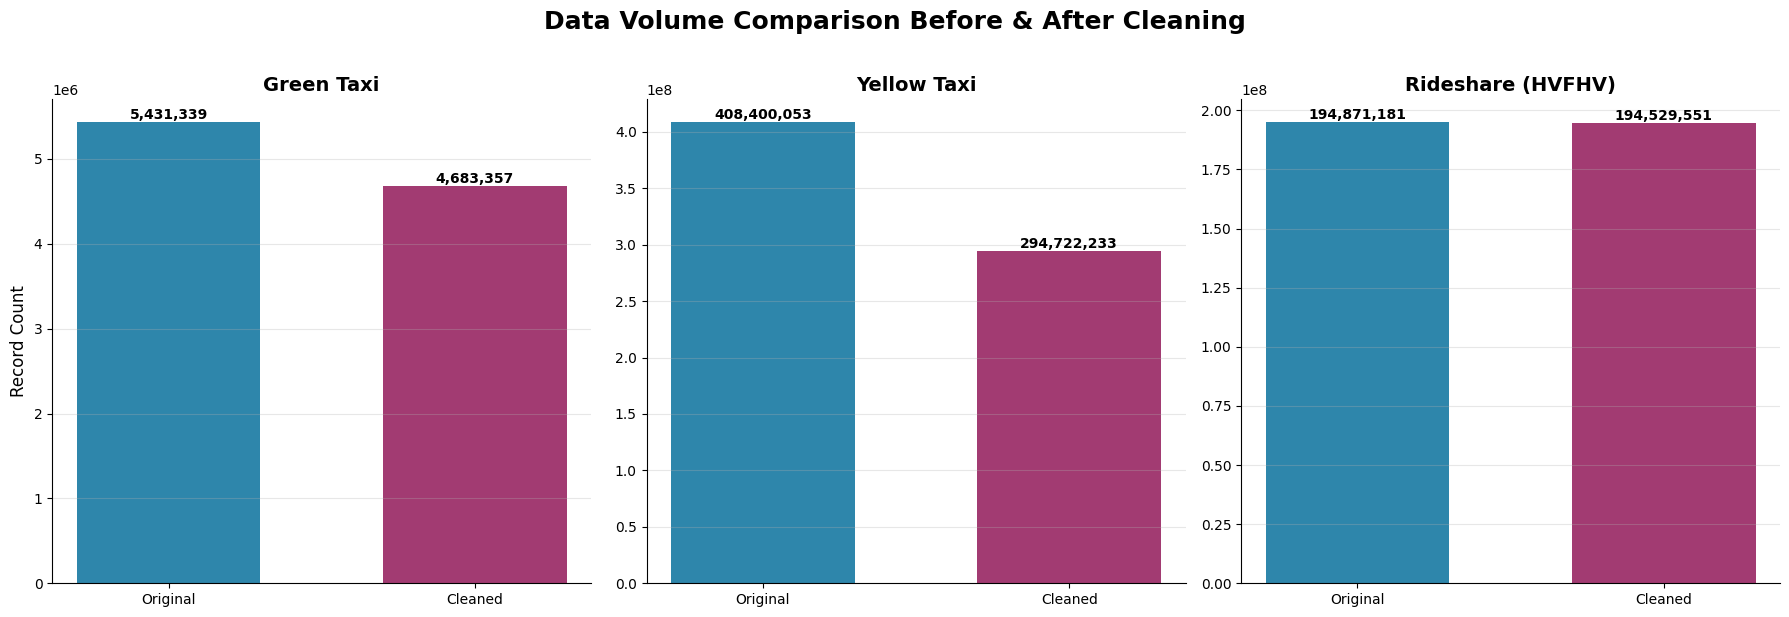

In [0]:
import matplotlib.pyplot as plt

# ---------------------- Data (using the values you provided) ----------------------
labels = ["Original", "Cleaned"]  
colors = ["#2E86AB", "#A23B72"]   

# Three datasets: original data volume → cleaned data volume
green_taxi =   [5431339,   4683357]   # Green taxi
yellow_taxi = [408400053, 294722233] # Yellow taxi
rideshare =   [194871181, 194529551] # Rideshare

# ---------------------- Plotting (one figure with 3 subplots) ----------------------
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Subplot 1: Green Taxi
ax1.bar(labels, green_taxi, color=colors, width=0.6)
ax1.set_title("Green Taxi", fontsize=14, fontweight='bold')
ax1.set_ylabel("Record Count", fontsize=12)
# Display values
ax1.text(0, green_taxi[0], f"{green_taxi[0]:,}", ha='center', va='bottom', fontweight='bold')
ax1.text(1, green_taxi[1], f"{green_taxi[1]:,}", ha='center', va='bottom', fontweight='bold')

# Subplot 2: Yellow Taxi
ax2.bar(labels, yellow_taxi, color=colors, width=0.6)
ax2.set_title("Yellow Taxi", fontsize=14, fontweight='bold')
ax2.text(0, yellow_taxi[0], f"{yellow_taxi[0]:,}", ha='center', va='bottom', fontweight='bold')
ax2.text(1, yellow_taxi[1], f"{yellow_taxi[1]:,}", ha='center', va='bottom', fontweight='bold')

# Subplot 3: Rideshare
ax3.bar(labels, rideshare, color=colors, width=0.6)
ax3.set_title("Rideshare (HVFHV)", fontsize=14, fontweight='bold')
ax3.text(0, rideshare[0], f"{rideshare[0]:,}", ha='center', va='bottom', fontweight='bold')
ax3.text(1, rideshare[1], f"{rideshare[1]:,}", ha='center', va='bottom', fontweight='bold')

# Main title
fig.suptitle("Data Volume Comparison Before & After Cleaning", fontsize=18, fontweight='bold', y=1.02)

# Unified styling
for ax in [ax1, ax2, ax3]:
    ax.spines[['top', 'right']].set_visible(False)  # Remove extra borders
    ax.grid(axis='y', alpha=0.3)                     # Light grid

plt.tight_layout()
plt.show()

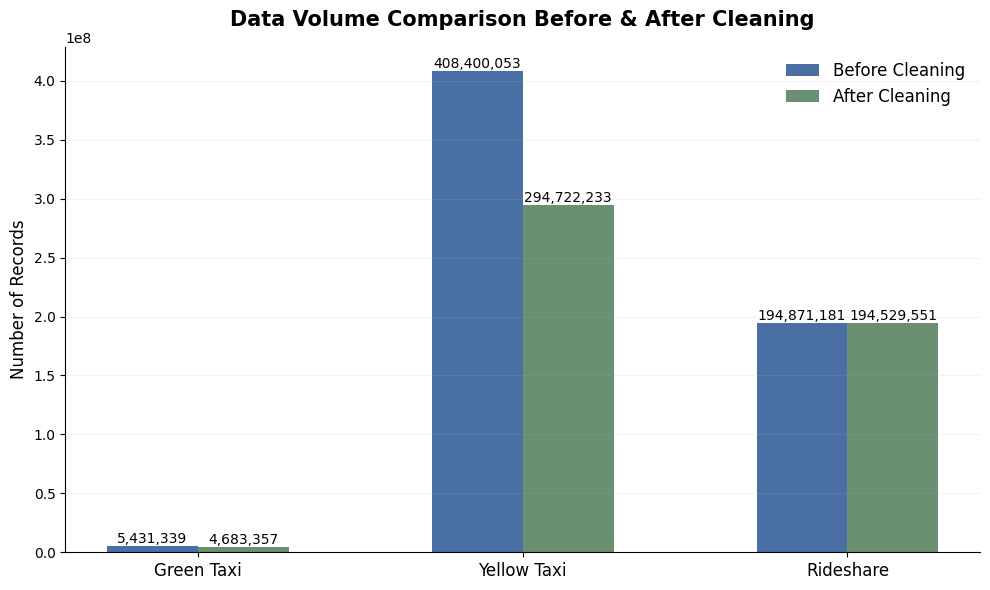

In [0]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------- Data  ----------------------
categories = ['Green Taxi', 'Yellow Taxi', 'Rideshare']
before = [5431339, 408400053, 194871181]   # 清洗前
after  = [4683357, 294722233, 194529551]   # 清洗后

x = np.arange(len(categories))
width = 0.28  # Slender bars

# ----------------------  Advanced Color Scheme (Low Saturation · Business/Academic Style) ----------------------
color_before = "#4A6FA5"   # Premium misty blue
color_after  = "#6B8F71"   # Low-saturation dark green

# ---------------------- Plotting ----------------------
plt.figure(figsize=(10, 6))

# Grouped slender bar chart
plt.bar(x - width/2, before, width, label='Before Cleaning', color=color_before)
plt.bar(x + width/2, after,  width, label='After Cleaning',  color=color_after)

# ---------------------- Styling ----------------------
plt.title('Data Volume Comparison Before & After Cleaning', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('Number of Records', fontsize=12)
plt.xticks(x, categories, fontsize=12)
plt.legend(fontsize=12, frameon=False)  

# Minimalist borders 
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.15)  

# Display numeric labels
for i, v in enumerate(before):
    plt.text(i - width/2, v, f'{v:,}', ha='center', va='bottom', fontsize=10)
for i, v in enumerate(after):
    plt.text(i + width/2, v, f'{v:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()